In [1]:
import numpy as np
import pandas as pd
import statistics
import seaborn as sns
import os
import subprocess
import shutil
import plotly.express as px
import sys
sys.path.append('/gpfs/commons/home/mgarbulowski/homic_package/src') 
from homic import file_readers, kraken2, process_data, make_plots
from collections import Counter
from scipy import stats
import matplotlib.pyplot as plt

homic package imported


In [2]:
## ONT
file1 = "/gpfs/commons/home/mgarbulowski/016_proj_shm/data_polyA_comparison/blastn_rs3/control_rep1_blastn_report.txt"

df1 = process_data.read_n_clean_blastn(file1, db = "rs", top_hits = True, evalue = 1e-100,
                          pident=0.98, drop_sp = True, drop_uncultured = True,
                          drop_bacterium=True, drop_virus=True, best_unique = False)

file2 = "/gpfs/commons/home/mgarbulowski/016_proj_shm/data_polyA_comparison/blastn_rs3/control_rep2_blastn_report.txt"

df2 = process_data.read_n_clean_blastn(file2, db = "rs", top_hits = True, evalue = 1e-100,
                          pident=0.98, drop_sp = True, drop_uncultured = True,
                          drop_bacterium=True, drop_virus=True, best_unique = False)

file3 = "/gpfs/commons/home/mgarbulowski/016_proj_shm/data_polyA_comparison/blastn_rs3/polyA_blastn_report.txt"

df3 = process_data.read_n_clean_blastn(file3, db = "rs", top_hits = True, evalue = 1e-100,
                          pident=0.98, drop_sp = True, drop_uncultured = True,
                          drop_bacterium=True, drop_virus=True, best_unique = False)

In [3]:
path_ctgs1 = "/gpfs/commons/home/mgarbulowski/016_proj_shm/data_polyA_comparison/metagenome_contigs_control_rep1.fastq"
path_ctgs2 = "/gpfs/commons/home/mgarbulowski/016_proj_shm/data_polyA_comparison/metagenome_contigs_control_rep2.fastq"
path_ctgs3 = "/gpfs/commons/home/mgarbulowski/016_proj_shm/data_polyA_comparison/metagenome_contigs_polyA.fastq"

prc_ctrl = process_data.perc_contigs_assigned(file1, path_ctgs1)
prc_polyA = process_data.perc_contigs_assigned(file2, path_ctgs2)
prc_polyA_bal = process_data.perc_contigs_assigned(file3, path_ctgs3)

print(prc_ctrl)
print(prc_polyA)
print(prc_polyA_bal)

0.7400216834881356
0.7391587577918796
0.9490143587247506


(0, 1)
(0, 2524)
(0, 1009)


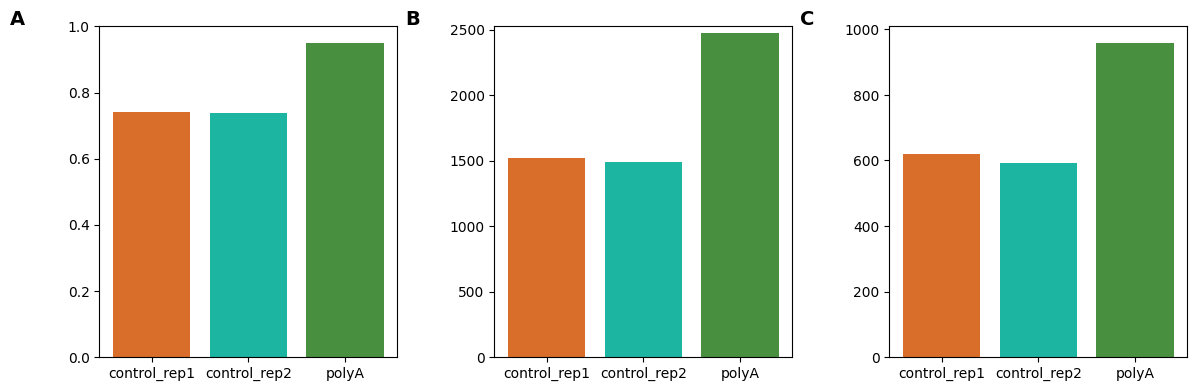

In [4]:
# Sample data
categories = ['control_rep1','control_rep2', 'polyA']
values1 = [prc_ctrl, prc_polyA, prc_polyA_bal]
values2 = [len(set(df1["species"])), len(set(df2["species"])), len(set(df3["species"]))]
values3 = [len(set(df1["genus"])), len(set(df2["genus"])), len(set(df3["genus"]))]

# Create figure and subplots
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# List of data and labels
datasets = [(values1, 'A'), (values2, 'B'), (values3, 'C')]
ylim_vals = [(0,1),(0,max(values2)+50),(0,max(values3)+50)]
y_labels = ['Amount of assigned contigs', 'Number of detected species', 'Number of detected genera']
for ax, (values, label), y_label, yvals in zip(axes, datasets, y_labels, ylim_vals):
    ax.bar(categories, values, color=['#D96E2B', '#1BB5A1', '#488F40'])
    # Add letter label in top-left corner
    print(yvals)
    ax.set_ylim(yvals)
    
    ax.text(-0.3, 1.05, label, transform=ax.transAxes,
            fontsize=14, fontweight='bold', va='top', ha='left')

plt.tight_layout()
plt.show()

fig.savefig("/gpfs/commons/home/mgarbulowski/016_proj_shm/data_polyA_comparison/figs/polyA_vs_ctrl_ONT", dpi=300, bbox_inches='tight')

In [5]:
### ctrl ###
samps_ids = ["control_rep1","control_rep1"]
path_blast = "/gpfs/commons/home/mgarbulowski/016_proj_shm/data_polyA_comparison/blastn_rs3/"
c01, c005, c001, df_ctrl = process_data.select_taxa(path_blast, samps_ids, taxa_level="species", db="rs")

### poly A ###
samps_ids = ["polyA"]
pa01, pa005, pa001, df_polya = process_data.select_taxa(path_blast, samps_ids, taxa_level="species", db="rs")

In [6]:
print("control")
print("0.1%")
print(len(c01))
print("")
print("0.05%")
print(len(c005))
print("")
print("0.01%")
print(len(c001))

control
0.1%
131

0.05%
186

0.01%
404


In [7]:
print("polyA")
print("0.1%")
print(len(pa01))
print("")
print("0.05%")
print(len(pa005))
print("")
print("0.01%")
print(len(pa001))

polyA
0.1%
125

0.05%
194

0.01%
484


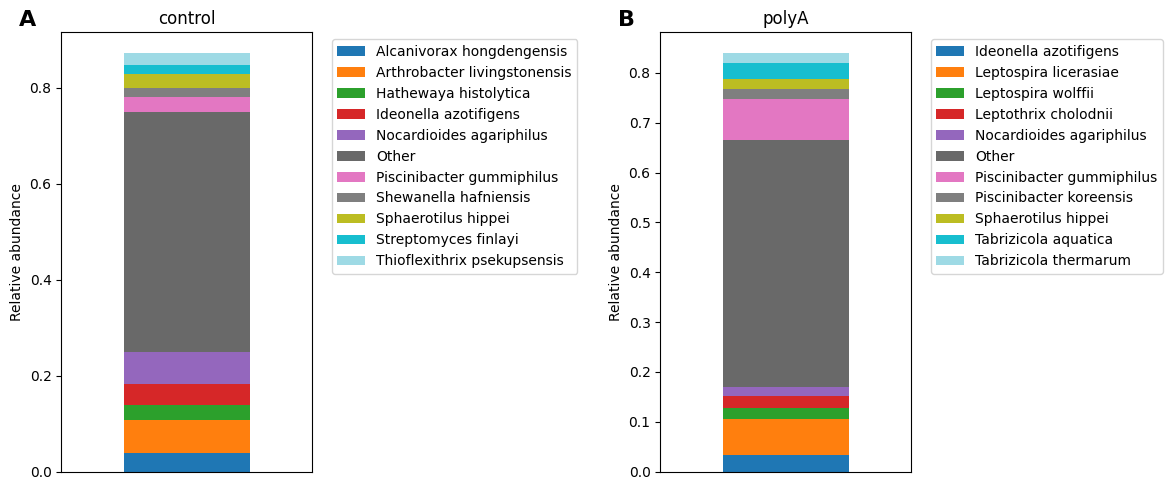

In [8]:
ntop = 10
## species level female
vals_f = c01.values.tolist()
inds_f = c01.index.tolist()
inds_f2 = [name if val >= vals_f[ntop-1] else "Other" for name, val in zip(inds_f, vals_f)]

df_s_f = pd.DataFrame({'abundance': vals_f},
                  index=inds_f2)

## species level female
vals_m = pa01.values.tolist()
inds_m = pa01.index.tolist()
inds_m2 = [name if val >= vals_m[ntop-1] else "Other" for name, val in zip(inds_m, vals_m)]

df_s_m = pd.DataFrame({'abundance': vals_m},
                  index=inds_m2)

df_s_f = df_s_f.groupby(df_s_f.index).sum()
df_s_m = df_s_m.groupby(df_s_m.index).sum()

fig = make_plots.relative_abundance_double(df_s_f, df_s_m,"control","polyA")
fig.savefig("/gpfs/commons/home/mgarbulowski/016_proj_shm/data_polyA_comparison/figs/relative_abundance_species_ctrlpolyA_0.1%_rs.png", dpi=300, bbox_inches='tight')

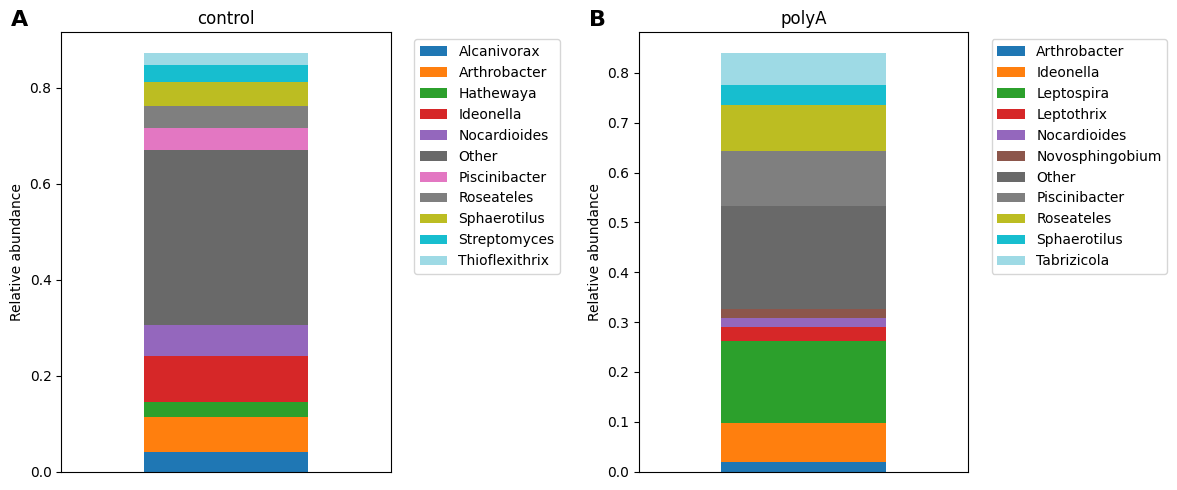

In [9]:
## genus level (based on species)
#female
s1 = c01.index.to_list()
s2 = [s.split()[0] for s in s1]

gfbc01 = c01.set_axis(s2, axis='index')
gfbc01 = gfbc01.groupby(level=0).sum()
gfbc01 = gfbc01.sort_values(ascending=False)
#male
s1 = pa01.index.to_list()
s2 = [s.split()[0] for s in s1]

gmbc01 = pa01.set_axis(s2, axis='index')
gmbc01 = gmbc01.groupby(level=0).sum()
gmbc01 = gmbc01.sort_values(ascending=False)

ntop = 10
## species level female
vals_f = gfbc01.values.tolist()
inds_f = gfbc01.index.tolist()
inds_f2 = [name if val >= vals_f[ntop-1] else "Other" for name, val in zip(inds_f, vals_f)]

df_s_f = pd.DataFrame({'abundance': vals_f},
                  index=inds_f2)

## species level female
vals_m = gmbc01.values.tolist()
inds_m = gmbc01.index.tolist()
inds_m2 = [name if val >= vals_m[ntop-1] else "Other" for name, val in zip(inds_m, vals_m)]

df_s_m = pd.DataFrame({'abundance': vals_m},
                  index=inds_m2)

df_s_f = df_s_f.groupby(df_s_f.index).sum()
df_s_m = df_s_m.groupby(df_s_m.index).sum()

fig = make_plots.relative_abundance_double(df_s_f, df_s_m,"control","polyA")
fig.savefig("/gpfs/commons/home/mgarbulowski/016_proj_shm/data_polyA_comparison/figs/relative_abundance_genus_ctrlplya_0.1%_rs.png", dpi=300, bbox_inches='tight')


Text(0.05, 0.95, 'r = 0.48\np = 2.160e-164')

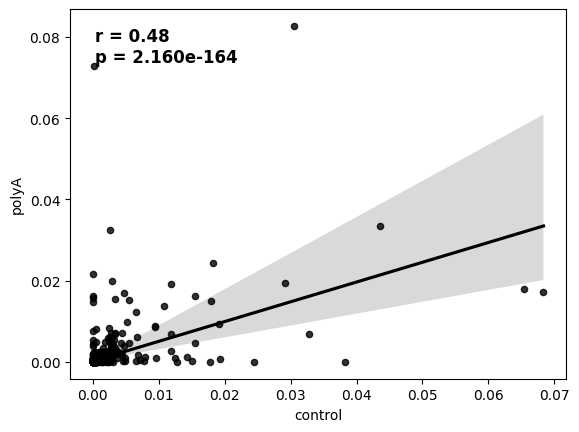

In [10]:
listed_data = [df_ctrl, df_polya]
counts = [Counter(df["species"]) for df in listed_data]
data_names = ["control","polyA"]
# create DataFrame from all counts
df = pd.DataFrame(counts).fillna(0).astype(int)
df = df.T
df.columns = data_names

df['control']= (df['control']/df['control'].sum()) 
df['polyA']= (df['polyA']/df['polyA'].sum()) 

# 1
g = sns.regplot(x=data_names[0], y=data_names[1], data=df, scatter_kws={'s':20, 'color': 'black'}, line_kws={'color': 'black'})
res = stats.pearsonr(df[data_names[0]], df[data_names[1]])
    
g.text(
    0.05, 0.95,
    f"r = {res[0]:.2f}\n"
    f"p = {res[1]:.3e}",
    transform=g.transAxes,
    ha="left", va="top",
    fontsize=12, weight="bold"
    )

Text(0.05, 0.95, 'r = 0.53\np = 7.046e-76')

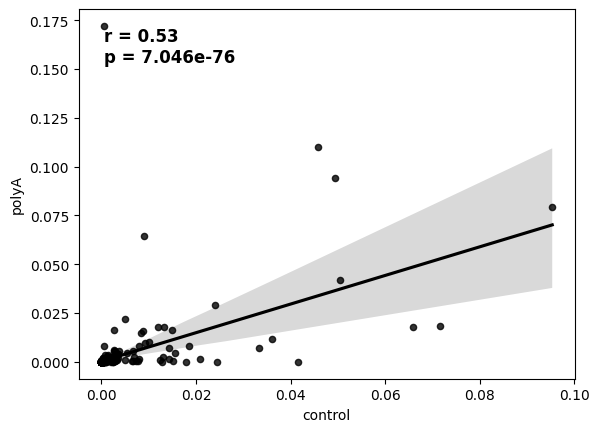

In [11]:
listed_data = [df_ctrl, df_polya]
counts = [Counter(df["genus"]) for df in listed_data]
data_names = ["control","polyA"]
# create DataFrame from all counts
df = pd.DataFrame(counts).fillna(0).astype(int)
df = df.T
df.columns = data_names

df['control']= (df['control']/df['control'].sum()) 
df['polyA']= (df['polyA']/df['polyA'].sum()) 

# 1
g = sns.regplot(x=data_names[0], y=data_names[1], data=df, scatter_kws={'s':20, 'color': 'black'}, line_kws={'color': 'black'})
res = stats.pearsonr(df[data_names[0]], df[data_names[1]])
    
g.text(
    0.05, 0.95,
    f"r = {res[0]:.2f}\n"
    f"p = {res[1]:.3e}",
    transform=g.transAxes,
    ha="left", va="top",
    fontsize=12, weight="bold"
    )

In [4]:
## ## ## ## ## Illumina ## ## ## ## ## ## 
## ## ## ## ## ## ## ## ## ## ## ## ## ## 

file1 = "/gpfs/commons/home/mgarbulowski/016_proj_shm/data_polyA_comparison/illumina_data/blastn_rs/control_blastn_report.txt"

df1 = process_data.read_n_clean_blastn(file1, db = "rs", top_hits = True, evalue = 1e-100,
                          pident=0.98, drop_sp = True, drop_uncultured = True,
                          drop_bacterium=True, drop_virus=True, best_unique = False)

file2 = "/gpfs/commons/home/mgarbulowski/016_proj_shm/data_polyA_comparison/illumina_data/blastn_rs/polyA_balanced_blastn_report.txt"

df2 = process_data.read_n_clean_blastn(file2, db = "rs", top_hits = True, evalue = 1e-100,
                          pident=0.98, drop_sp = True, drop_uncultured = True,
                          drop_bacterium=True, drop_virus=True, best_unique = False)

file3 = "/gpfs/commons/home/mgarbulowski/016_proj_shm/data_polyA_comparison/illumina_data/blastn_rs/polyA_blastn_report.txt"

df3 = process_data.read_n_clean_blastn(file3, db = "rs", top_hits = True, evalue = 1e-100,
                          pident=0.98, drop_sp = True, drop_uncultured = True,
                          drop_bacterium=True, drop_virus=True, best_unique = False)

In [6]:
path_ctgs1 = "/gpfs/commons/home/mgarbulowski/016_proj_shm/data_polyA_comparison/illumina_data/metagenome_contigs_control.fastq"
path_ctgs2 = "/gpfs/commons/home/mgarbulowski/016_proj_shm/data_polyA_comparison/illumina_data/metagenome_contigs_polyA_balanced.fastq"
path_ctgs3 = "/gpfs/commons/home/mgarbulowski/016_proj_shm/data_polyA_comparison/illumina_data/metagenome_contigs_polyA.fastq"

prc_ctrl = process_data.perc_contigs_assigned(file1, path_ctgs1)
prc_polyA = process_data.perc_contigs_assigned(file2, path_ctgs2)
prc_polyA_bal = process_data.perc_contigs_assigned(file3, path_ctgs3)

print(prc_ctrl)
print(prc_polyA)
print(prc_polyA_bal)

0.7867647058823529
0.9769820971867008
0.9548872180451128


(0, 100)
(0, 216)
(0, 129)


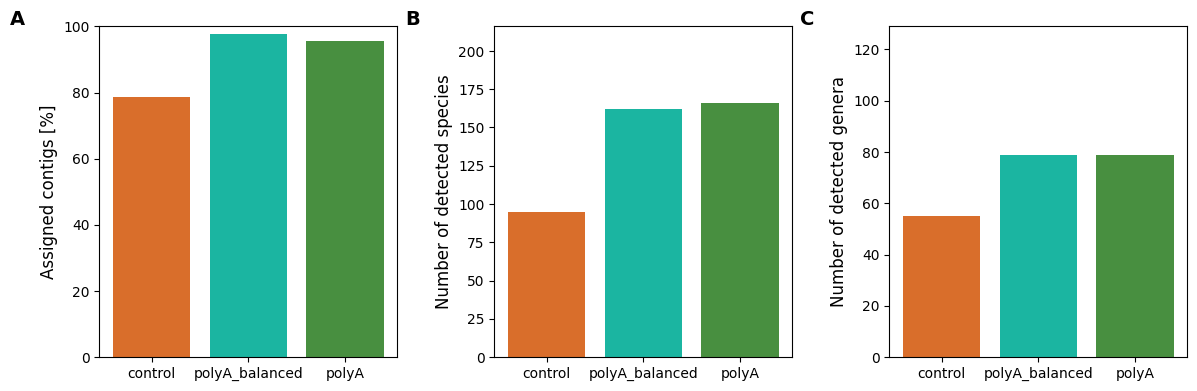

In [9]:
# Sample data
categories = ['control','polyA_balanced', 'polyA']
values1 = [prc_ctrl*100, prc_polyA*100, prc_polyA_bal*100]
values2 = [len(set(df1["species"])), len(set(df2["species"])), len(set(df3["species"]))]
values3 = [len(set(df1["genus"])), len(set(df2["genus"])), len(set(df3["genus"]))]

# Create figure and subplots
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# List of data and labels
datasets = [(values1, 'A'), (values2, 'B'), (values3, 'C')]
ylim_vals = [(0,100),(0,max(values2)+50),(0,max(values3)+50)]
y_labels = ['Assigned contigs [%]', 'Number of detected species', 'Number of detected genera']
for ax, (values, label), y_label, yvals in zip(axes, datasets, y_labels, ylim_vals):
    ax.bar(categories, values, color=['#D96E2B', '#1BB5A1', '#488F40'])
    # Add letter label in top-left corner
    print(yvals)
    ax.set_ylim(yvals)
    ax.set_ylabel(y_label, fontsize=12)
    ax.text(-0.3, 1.05, label, transform=ax.transAxes,
            fontsize=14, fontweight='bold', va='top', ha='left')

plt.tight_layout()
plt.show()

fig.savefig("/gpfs/commons/home/mgarbulowski/016_proj_shm/data_polyA_comparison/figs/polyA_vs_ctrl_illumina", dpi=300, bbox_inches='tight')

In [57]:
### ctrl ###
bcounts = df1["species"].value_counts(normalize=True)

c01 = bcounts[0:50]
c005 = bcounts[bcounts > 0.005 * 0.01]
c001 = bcounts[bcounts > 0.001 * 0.01]
df_ctrl = df1
samps_ids = ["control"]

### poly A ###
bcounts = df2["species"].value_counts(normalize=True)

pa01 = bcounts[0:50]
pa005 = bcounts[bcounts > 0.005 * 0.01]
pa001 = bcounts[bcounts > 0.001 * 0.01]
df_polya = df2

print("control")
print("0.1%")
print(len(c01))
print("")
print("0.05%")
print(len(c005))
print("")
print("0.01%")
print(len(c001))

print("polyA")
print("0.1%")
print(len(pa01))
print("")
print("0.05%")
print(len(pa005))
print("")
print("0.01%")
print(len(pa001))

control
0.1%
50

0.05%
95

0.01%
95
polyA
0.1%
50

0.05%
162

0.01%
162


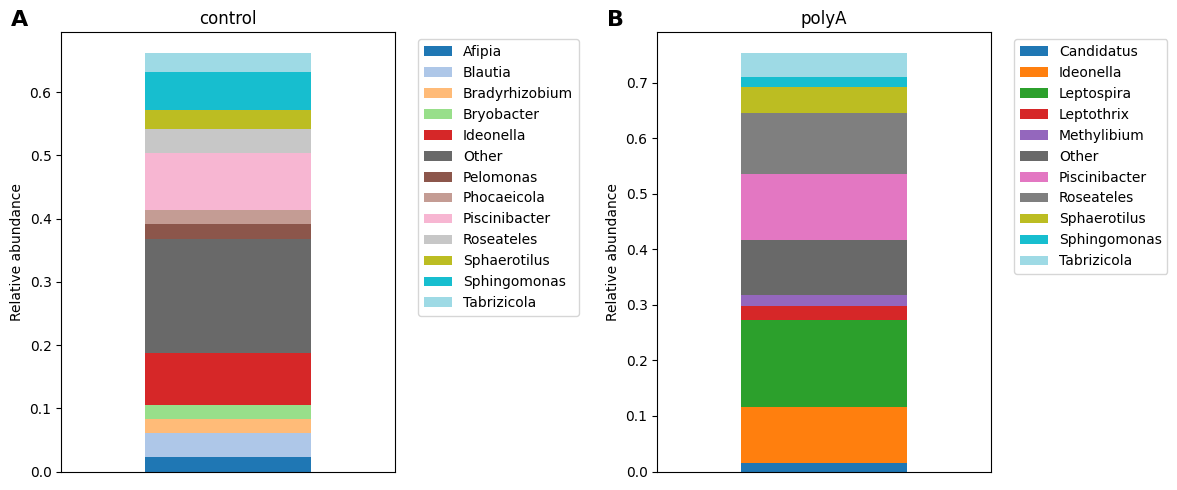

In [52]:
## genus level (based on species)
#female
s1 = c01.index.to_list()
s2 = [s.split()[0] for s in s1]

gfbc01 = c01.set_axis(s2, axis='index')
gfbc01 = gfbc01.groupby(level=0).sum()
gfbc01 = gfbc01.sort_values(ascending=False)
#male
s1 = pa01.index.to_list()
s2 = [s.split()[0] for s in s1]

gmbc01 = pa01.set_axis(s2, axis='index')
gmbc01 = gmbc01.groupby(level=0).sum()
gmbc01 = gmbc01.sort_values(ascending=False)

ntop = 10
## species level female
vals_f = gfbc01.values.tolist()
inds_f = gfbc01.index.tolist()
inds_f2 = [name if val >= vals_f[ntop-1] else "Other" for name, val in zip(inds_f, vals_f)]

df_s_f = pd.DataFrame({'abundance': vals_f},
                  index=inds_f2)

## species level female
vals_m = gmbc01.values.tolist()
inds_m = gmbc01.index.tolist()
inds_m2 = [name if val >= vals_m[ntop-1] else "Other" for name, val in zip(inds_m, vals_m)]

df_s_m = pd.DataFrame({'abundance': vals_m},
                  index=inds_m2)

df_s_f = df_s_f.groupby(df_s_f.index).sum()
df_s_m = df_s_m.groupby(df_s_m.index).sum()

fig = make_plots.relative_abundance_double(df_s_f, df_s_m,"control","polyA")
fig.savefig("/gpfs/commons/home/mgarbulowski/016_proj_shm/data_polyA_comparison/figs/relative_abundance_genus_ctrlplya_0.1%_rs_illumina.png", dpi=300, bbox_inches='tight')


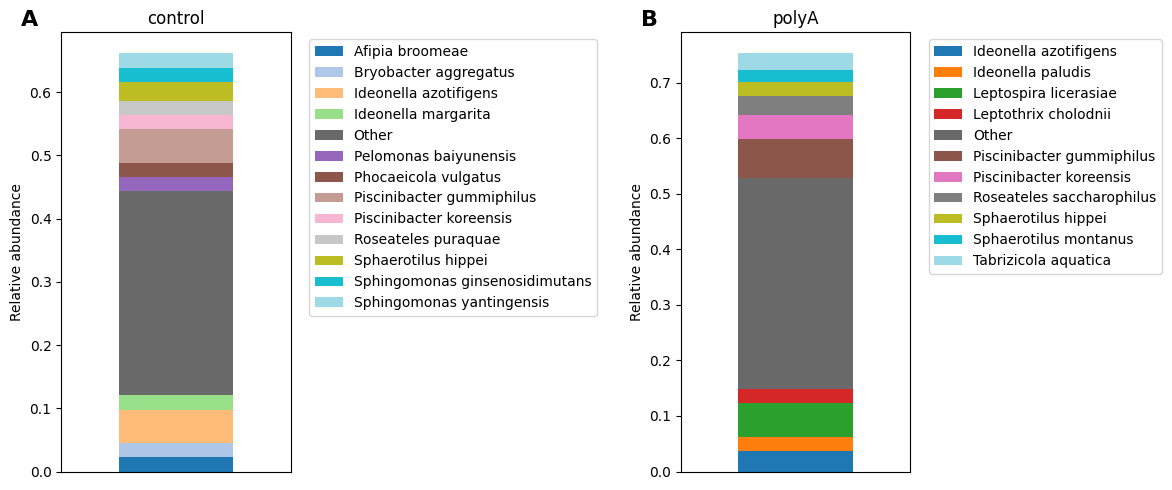

In [55]:
ntop = 10
## species level female
vals_f = c01.values.tolist()
inds_f = c01.index.tolist()
inds_f2 = [name if val >= vals_f[ntop-1] else "Other" for name, val in zip(inds_f, vals_f)]

df_s_f = pd.DataFrame({'abundance': vals_f},
                  index=inds_f2)

## species level female
vals_m = pa01.values.tolist()
inds_m = pa01.index.tolist()
inds_m2 = [name if val >= vals_m[ntop-1] else "Other" for name, val in zip(inds_m, vals_m)]

df_s_m = pd.DataFrame({'abundance': vals_m},
                  index=inds_m2)

df_s_f = df_s_f.groupby(df_s_f.index).sum()
df_s_m = df_s_m.groupby(df_s_m.index).sum()

fig = make_plots.relative_abundance_double(df_s_f, df_s_m,"control","polyA")
fig.savefig("/gpfs/commons/home/mgarbulowski/016_proj_shm/data_polyA_comparison/figs/relative_abundance_species_ctrlpolyA_0.1%_rs_illumina.png", dpi=300, bbox_inches='tight')

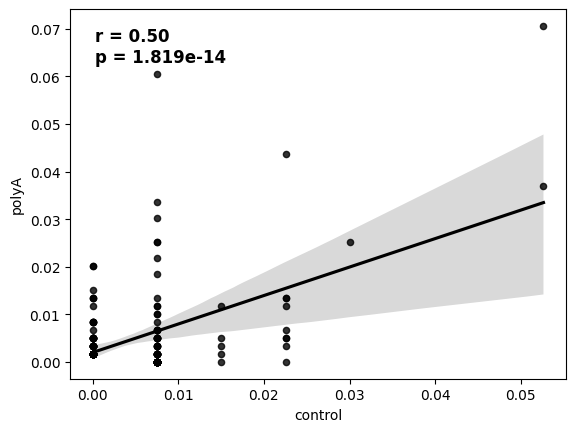

In [59]:
listed_data = [df_ctrl, df_polya]
counts = [Counter(df["species"]) for df in listed_data]
data_names = ["control","polyA"]
# create DataFrame from all counts
df = pd.DataFrame(counts).fillna(0).astype(int)
df = df.T
df.columns = data_names

df['control']= (df['control']/df['control'].sum()) 
df['polyA']= (df['polyA']/df['polyA'].sum()) 

# 1
g = sns.regplot(x=data_names[0], y=data_names[1], data=df, scatter_kws={'s':20, 'color': 'black'}, line_kws={'color': 'black'})
res = stats.pearsonr(df[data_names[0]], df[data_names[1]])
    
g.text(
    0.05, 0.95,
    f"r = {res[0]:.2f}\n"
    f"p = {res[1]:.3e}",
    transform=g.transAxes,
    ha="left", va="top",
    fontsize=12, weight="bold"
    )



Text(0.05, 0.95, 'r = 0.73\np = 1.746e-17')

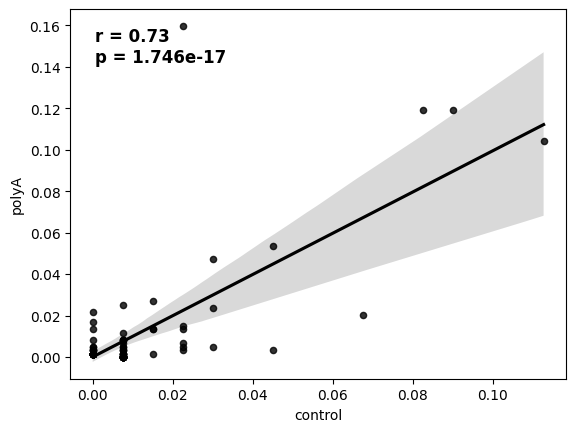

In [54]:
listed_data = [df_ctrl, df_polya]
counts = [Counter(df["genus"]) for df in listed_data]
data_names = ["control","polyA"]
# create DataFrame from all counts
df = pd.DataFrame(counts).fillna(0).astype(int)
df = df.T
df.columns = data_names

df['control']= (df['control']/df['control'].sum()) 
df['polyA']= (df['polyA']/df['polyA'].sum()) 

# 1
g = sns.regplot(x=data_names[0], y=data_names[1], data=df, scatter_kws={'s':20, 'color': 'black'}, line_kws={'color': 'black'})
res = stats.pearsonr(df[data_names[0]], df[data_names[1]])
    
g.text(
    0.05, 0.95,
    f"r = {res[0]:.2f}\n"
    f"p = {res[1]:.3e}",
    transform=g.transAxes,
    ha="left", va="top",
    fontsize=12, weight="bold"
    )

In [6]:
## ## ## ## ## ## ## ## ## ## ## ## ## 
## ## ## ## KRAKEN 2 ## ## ## ## ## ## 
## ## ## ## ## ## ## ## ## ## ## ## ## 
import numpy as np
import pandas as pd
import statistics
import seaborn as sns
import os
import subprocess
import shutil
import plotly.express as px
import sys
sys.path.append('/gpfs/commons/home/mgarbulowski/homic_package/src') 
from homic import file_readers, kraken2, process_data, make_plots
from collections import Counter
from scipy import stats
import matplotlib.pyplot as plt

path1 = "/gpfs/commons/home/mgarbulowski/016_proj_shm/data_polyA_comparison/illumina_data/Lib9_krk.csv" # lib9 is control
path2 = "/gpfs/commons/home/mgarbulowski/016_proj_shm/data_polyA_comparison/illumina_data/Lib15_krk.csv"

out1 = kraken2.taxid_to_taxainfo(path1) 
out2 = kraken2.taxid_to_taxainfo(path2)

In [7]:
specs_1 = out1[out1["species"] != "unassigned"]
specs_1 = specs_1[specs_1["species"] != "Homo sapiens"]
specs_1 = specs_1["species"]

specs_2 = out2[out2["species"] != "unassigned"]
specs_2 = specs_2[specs_2["species"] != "Homo sapiens"]
specs_2 = specs_2["species"]

gens_1 = out1[out1["genus"] != "unassigned"]
gens_1 = gens_1[gens_1["genus"] != "Homo"]
gens_1 = gens_1["genus"]

gens_2 = out2[out2["genus"] != "unassigned"]
gens_2 = gens_2[gens_2["genus"] != "Homo"]
gens_2 = gens_2["genus"]

bac_1 = out1[out1["superkingdom"] == "Bacteria"]
bac_1 = bac_1["superkingdom"]
bac_2 = out2[out2["superkingdom"] == "Bacteria"]
bac_2 = bac_2["superkingdom"]

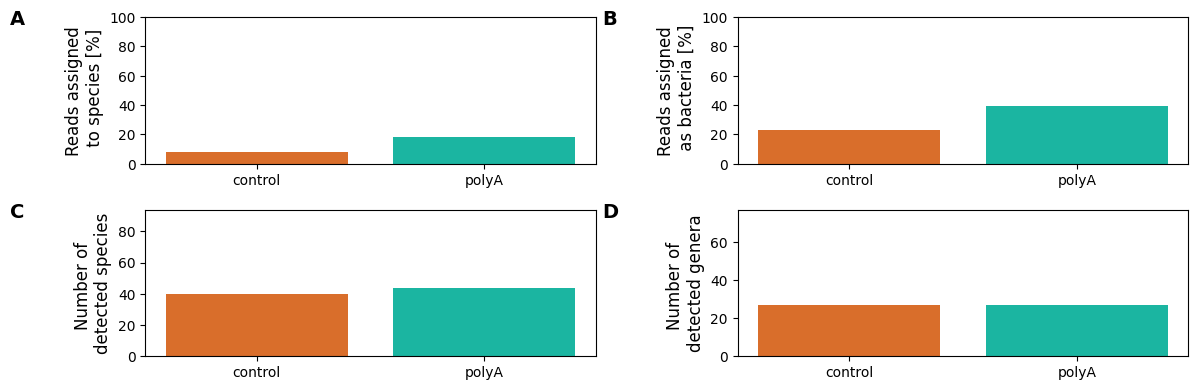

In [8]:
# Sample data
categories = ['control','polyA']

krk_out1 =  pd.read_csv(path1)
krk_out2 =  pd.read_csv(path2)

prc_ctrl1 = len(specs_1)/krk_out1.shape[0]
prc_polyA1 = len(specs_2)/krk_out2.shape[0]

prc_ctrl2 = len(bac_1)/krk_out1.shape[0]
prc_polyA2 = len(bac_2)/krk_out2.shape[0]

values1 = [prc_ctrl1*100, prc_polyA1*100]
values2 = [prc_ctrl2*100, prc_polyA2*100]
values3 = [len(set(specs_1)), len(set(specs_2))]
values4 = [len(set(gens_1)), len(set(gens_1))]

# Create figure and subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 4))
axes = axes.flatten()  # Flatten 2x2 array into a 1D list

# List of data and labels
datasets = [(values1, 'A'), (values2, 'B'), (values3, 'C'), (values4, 'D')]
ylim_vals = [(0,100),(0,100),(0,max(values3)+50),(0,max(values4)+50)]
y_labels = ['Reads assigned\n to species [%]',
            'Reads assigned\n as bacteria [%]',
            'Number of \ndetected species',
            'Number of \ndetected genera']

for ax, (values, label), y_label, yvals in zip(axes, datasets, y_labels, ylim_vals):
    ax.bar(categories, values, color=['#D96E2B', '#1BB5A1', '#488F40'])
    ax.set_ylim(yvals)
    ax.set_ylabel(y_label, fontsize=12)
    ax.text(-0.3, 1.05, label, transform=ax.transAxes,
            fontsize=14, fontweight='bold', va='top', ha='left')

plt.tight_layout()
plt.show()
fig.set_size_inches(8, 5)
fig.savefig("/gpfs/commons/home/mgarbulowski/016_proj_shm/data_polyA_comparison/figs/polyA_vs_ctrl_illumina_RC", dpi=300, bbox_inches='tight')

                                abundance
Subdoligranulum variabile            2235
Phoenicibacter congonensis           2150
Eshraghiella crossota                 699
Oscillibacter acetigenes              454
Akkermansia massiliensis              451
Thermophilibacter provencensis        444
Enterococcus hirae                    362
Streptococcus salivarius              324
Ruminococcus champanellensis          316
Ruminococcus callidus                 230


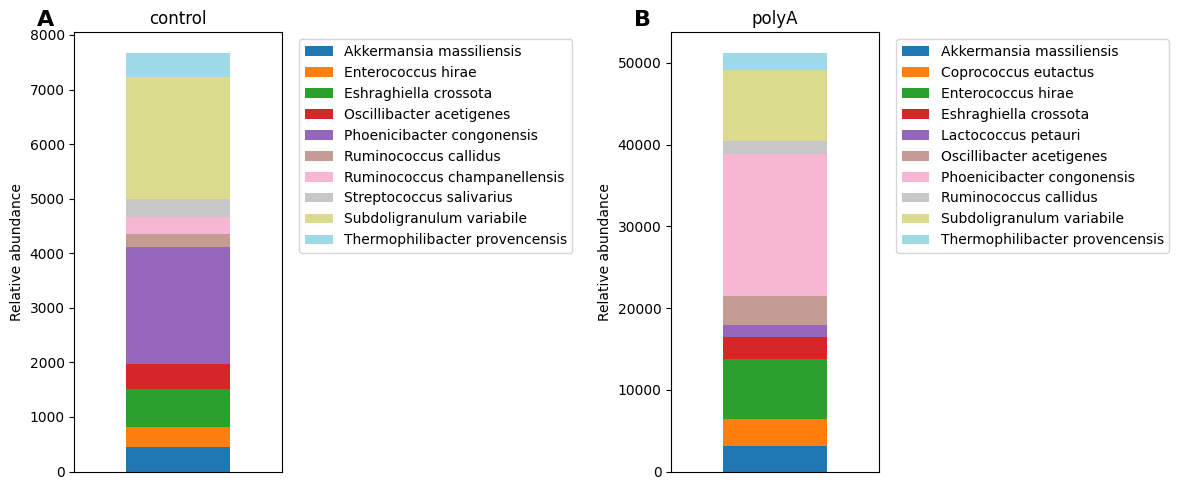

In [9]:
from collections import Counter
### ctrl ###
samps_ids = ["control_rep1","control_rep1"]

ntop = 10
c01 = Counter(specs_1)
c01 = c01.most_common(ntop)
pa01 = Counter(specs_2)
pa01 = pa01.most_common(ntop)


fe, se = zip(*c01)
vals_f = list(se)
inds_f = list(fe)

#vals_f = list(c01.values())
#inds_f = list(c01.keys())
#inds_f2 = [name if val >= vals_f[ntop-1] else "Other" for name, val in zip(inds_f, vals_f)]

df_s_f = pd.DataFrame({'abundance': vals_f},
                  index=inds_f)
fe, se = zip(*pa01)
vals_m = list(se)
inds_m = list(fe)
#inds_m2 = [name if val >= vals_m[ntop-1] else "Other" for name, val in zip(inds_m, vals_m)]
print(df_s_f)
df_s_m = pd.DataFrame({'abundance': vals_m},
                  index=inds_m)

df_s_f = df_s_f.groupby(df_s_f.index).sum()
df_s_m = df_s_m.groupby(df_s_m.index).sum()

fig = make_plots.relative_abundance_double(df_s_f, df_s_m,"control","polyA")
fig.savefig("/gpfs/commons/home/mgarbulowski/016_proj_shm/data_polyA_comparison/figs/relative_abundance_species_ctrlpolyA_0.1%_rs_illumina.png", dpi=300, bbox_inches='tight')

In [11]:
# ONT
path1 = "/gpfs/commons/home/mgarbulowski/016_proj_shm/data_polyA_comparison/ont_data/Lib9_krk.csv" # lib9 is control
path2 = "/gpfs/commons/home/mgarbulowski/016_proj_shm/data_polyA_comparison/ont_data/Lib15_krk.csv"

out1 = kraken2.taxid_to_taxainfo(path1) 
out2 = kraken2.taxid_to_taxainfo(path2)

specs_1 = out1[out1["species"] != "unassigned"]
specs_1 = specs_1[specs_1["species"] != "Homo sapiens"]
specs_1 = specs_1["species"]

specs_2 = out2[out2["species"] != "unassigned"]
specs_2 = specs_2[specs_2["species"] != "Homo sapiens"]
specs_2 = specs_2["species"]

gens_1 = out1[out1["genus"] != "unassigned"]
gens_1 = gens_1[gens_1["genus"] != "Homo"]
gens_1 = gens_1["genus"]

gens_2 = out2[out2["genus"] != "unassigned"]
gens_2 = gens_2[gens_2["genus"] != "Homo"]
gens_2 = gens_2["genus"]

bac_1 = out1[out1["superkingdom"] == "Bacteria"]
bac_1 = bac_1["superkingdom"]
bac_2 = out2[out2["superkingdom"] == "Bacteria"]
bac_2 = bac_2["superkingdom"]

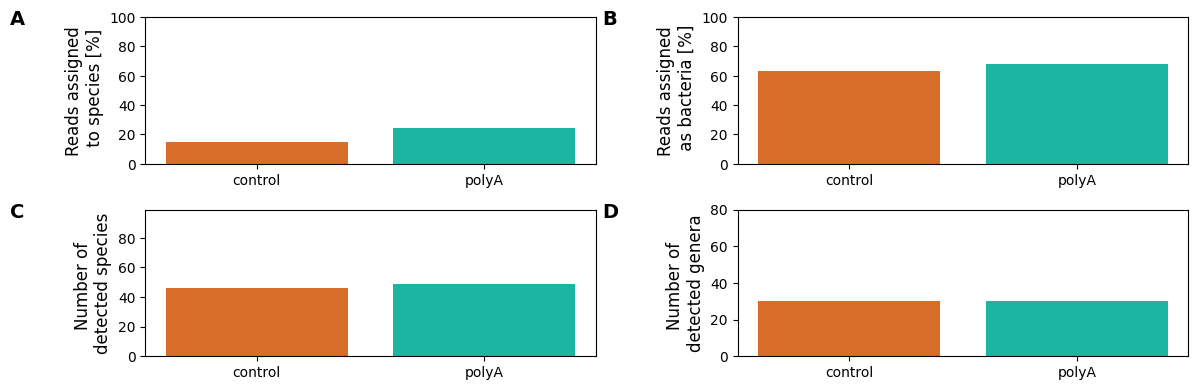

In [12]:
# Sample data
categories = ['control','polyA']

krk_out1 =  pd.read_csv(path1)
krk_out2 =  pd.read_csv(path2)

prc_ctrl1 = len(specs_1)/krk_out1.shape[0]
prc_polyA1 = len(specs_2)/krk_out2.shape[0]

prc_ctrl2 = len(bac_1)/krk_out1.shape[0]
prc_polyA2 = len(bac_2)/krk_out2.shape[0]

values1 = [prc_ctrl1*100, prc_polyA1*100]
values2 = [prc_ctrl2*100, prc_polyA2*100]
values3 = [len(set(specs_1)), len(set(specs_2))]
values4 = [len(set(gens_1)), len(set(gens_1))]

# Create figure and subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 4))
axes = axes.flatten()  # Flatten 2x2 array into a 1D list

# List of data and labels
datasets = [(values1, 'A'), (values2, 'B'), (values3, 'C'), (values4, 'D')]
ylim_vals = [(0,100),(0,100),(0,max(values3)+50),(0,max(values4)+50)]
y_labels = ['Reads assigned\n to species [%]',
            'Reads assigned\n as bacteria [%]',
            'Number of \ndetected species',
            'Number of \ndetected genera']

for ax, (values, label), y_label, yvals in zip(axes, datasets, y_labels, ylim_vals):
    ax.bar(categories, values, color=['#D96E2B', '#1BB5A1', '#488F40'])
    ax.set_ylim(yvals)
    ax.set_ylabel(y_label, fontsize=12)
    ax.text(-0.3, 1.05, label, transform=ax.transAxes,
            fontsize=14, fontweight='bold', va='top', ha='left')

plt.tight_layout()
plt.show()
fig.set_size_inches(8, 5)
fig.savefig("/gpfs/commons/home/mgarbulowski/016_proj_shm/data_polyA_comparison/figs/polyA_vs_ctrl_ont_RC", dpi=300, bbox_inches='tight')

                              abundance
Methylobacterium radiodurans    1023052
Comamonas endophytica            969972
Sphaerotilus sulfidivorans       314794
Aquabacterium olei               303789
Hathewaya histolytica            204033
Piscinibacter gummiphilus        118596
Leptothrix cholodnii              56203
Inhella inkyongensis              53469
Bordetella pertussis              19939
Echinicola soli                   19907


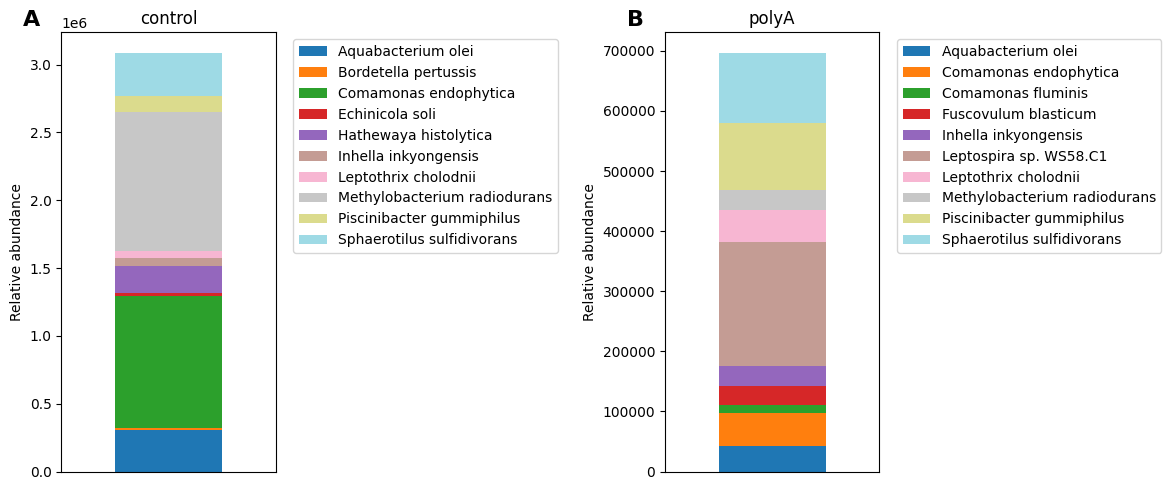

In [42]:
from collections import Counter
### ctrl ###
samps_ids = ["control_rep1","control_rep1"]

ntop = 10
c01 = Counter(gens_1)
c01 = c01.most_common(ntop)
pa01 = Counter(gens_2)
pa01 = pa01.most_common(ntop)


fe, se = zip(*c01)
vals_f = list(se)
inds_f = list(fe)

#vals_f = list(c01.values())
#inds_f = list(c01.keys())
#inds_f2 = [name if val >= vals_f[ntop-1] else "Other" for name, val in zip(inds_f, vals_f)]

df_s_f = pd.DataFrame({'abundance': vals_f},
                  index=inds_f)
fe, se = zip(*pa01)
vals_m = list(se)
inds_m = list(fe)
#inds_m2 = [name if val >= vals_m[ntop-1] else "Other" for name, val in zip(inds_m, vals_m)]
print(df_s_f)
df_s_m = pd.DataFrame({'abundance': vals_m},
                  index=inds_m)

df_s_f = df_s_f.groupby(df_s_f.index).sum()
df_s_m = df_s_m.groupby(df_s_m.index).sum()

fig = make_plots.relative_abundance_double(df_s_f, df_s_m,"control","polyA")
fig.savefig("/gpfs/commons/home/mgarbulowski/016_proj_shm/data_polyA_comparison/figs/relative_abundance_species_ctrlpolyA_0.1%_rs_ont.png", dpi=300, bbox_inches='tight')